# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

__Answer__: According to the "Materials and Methods" section of the paper, the data represents 17 campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
20994,34,technician,single,university.degree,no,no,no,telephone,aug,thu,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
11702,55,admin.,married,university.degree,no,no,no,telephone,jun,fri,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
9739,41,self-employed,married,basic.9y,no,yes,no,telephone,jun,mon,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
11103,46,blue-collar,married,basic.4y,unknown,no,no,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
15022,25,blue-collar,married,basic.4y,no,no,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



# Preliminary data understanding

List of categorical variables allowing an "unknown" value:
- job, marital, education, default, housing, loan

Further notes:
- It's suggested to drop the "duration" feature.
- The "pdays" feature having value 999 means the customer was not previously contacted.
- From the next cell, we see there are no na values, but there are some unknown values. (According to the above description, only certain columns allow an "unknown" value; these are listed below.)

In [4]:
# Get percentage of na vals in each column
print("Percentage of na values by column:")
print( df.isna().mean() * 100 ) # output shows no na vals in all columns!

# Get percentage of unknown values in each column that includes 'unknown' as a possibility
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
print("")
print("Percentage of unknown values by column:")
print( df[cols_with_unknown].eq('unknown').mean() * 100 )

Percentage of na values by column:
age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

Percentage of unknown values by column:
job           0.801204
marital       0.194231
education     4.202680
default      20.872584
housing       2.403613
loan          2.403613
dtype: float64


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

# Plan for feature encoding and transformation:

For simplicity, we will encode the target variable itself in the usual binary: "no" → 0, "yes" → 1.

For the following categorical features we will use ordinal encoding, and we will mean-impute the "unknown" values:
- default, housing, loan: "no" → 0, "yes" → 1.
- education: "illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree" respectively map to 0, 1, 2, 3, 4, 5, 6.

For the following categorical features without unknown values we will use ordinal encoding:
- poutcome: "failure" → -1, "nonexistent" → 0, "success" → +1.

For the following categorical features we will use one-hot encoding, except for unknown values which will be encoded as 0:
- job, marital, contact. (Note: the "contact" column doesn't have "unknown" entries.)

The following variables represent points in a temporal cycle (month of year, day of week). 
We will encode them using what we call a "unit circle encoding". Roughly, we encode them "geometrically on a circle". 
Specifically, for a cycle of length N -- e.g., N=12 months in a year, N=7 days in a week --
we first encode each value ordinally as an integer j from 1 to N, then we encode the integer j in 2D as ( cos(2 pi j/N) , sin(2 pi j/N) ) .
- month: "jan","feb","mar",...,"dec" are encoded as j=1,2,3,...,12. Here N=12.
- day_of_week: "mon","tues","wed","thurs","fri" are encoded as j=1,2,3,4,5. Here N=7, even though the two weekend days don't show up.

The following numerical variables will be handled as follows, and will then be standard-scaled: <!-- <span style="color:red">TODO</span> -->
- age: polynomial features.
- pdays: log-scale.
- previous, campaign: as-is.
- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed: as-is.

The numerical features, after the above steps, will be put through Standard Scaling.

In addition, we will add a column "previously_contacted", which is 0 or 1 according to whether "pdays" is 999 or not.


In [6]:
# # Check numbers of unique vals in these features which we plan to one-hot encode, to make sure they aren't too much for one-hot encoding.
# cols = ['job','marital','contact']
# for c in cols:
#     print(f'{c} has {len(df[c].unique())} unique vals')
comment=\
"""
Output:
job has 12 unique vals
marital has 4 unique vals
contact has 2 unique vals
"""

In [7]:
## Custom encoders:
## - mean-imputing ordinal encoder
## - "unit circle" encoder
## - zero-imputing one-hot encoder


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures




class MeanImputingOrdinalEncoder(BaseEstimator, TransformerMixin):
    """
    Notes: 
    - Here, 'mapping' is the dictionary mapping from non-unknown values to ordinals.
    - This encoder first ordinally encodes all non-unknown values using the mapping,
      then replaces the unknown values with the mean of the encoded non-unknown values.
    """
    
    def __init__(self, mapping, unknown_value='unknown'):
        self.mapping = mapping
        self.unknown_value = unknown_value
        self.mean_value_ = None

    def fit(self, X, y=None):
        # # Flatten, to be safe
        # X_flat = np.asarray(X).flatten()
        
        # Gather the mapped numerical values of non-unknown entries
        known_encoded = [
            self.mapping[val] for val in X # X_flat 
                if val in self.mapping 
                and val != self.unknown_value # exclude unknowns
        ]
        
        # Calculate and store the mean of non-unknown elements
        if known_encoded:
            self.mean_value_ = np.mean(known_encoded)
        else: # If no non-unknown values
            # Use the mean of the dictionary mapping's value list
            self.mean_value_ = np.mean(list(self.mapping.values()))
            
        return self

    def transform(self, X_in):
        X_in_arr = np.asarray(X_in)
        X_out = np.empty(X_in_arr.shape, dtype=float) # Output must be float to accommodate the mean decimal values

        # Compute the mapping on X_in_arr
        for i in range(X_in_arr.shape[0]):
            for j in range(X_in_arr.shape[1]):
                val = X_in_arr[i, j]
                if val == self.unknown_value:
                    X_out[i, j] = self.mean_value_
                elif val in self.mapping:
                    X_out[i, j] = self.mapping[val]
                else: # If previously unseen, non-unknown input value
                    X_out[i, j] = self.mean_value_ # use the training mean
                    
        return X_out

    def get_feature_names_out(self, input_features=None):
        # output feature names are just original name + '_ord'
        return np.asarray( [ f'{name}_ord' for name in input_features ] , dtype=object ) 


class UnitCircleEncoder(BaseEstimator, TransformerMixin): 
    
    def __init__(self, mapping, cycle_length_N, 
                 # feature_name_xcoord, feature_name_ycoord
                ):
        assert all(isinstance(val, int) for val in mapping.values()) # check to make sure "mapping" has integers for values
        assert isinstance(cycle_length_N, int) and cycle_length_N!=0 # check to make sure the cycle length N is a nonzero integer

        self.mapping = mapping
        self.cycle_length_N = cycle_length_N
        # self.feature_name_xcoord = feature_name_xcoord
        # self.feature_name_ycoord = feature_name_ycoord

    def fit(self, X, y=None):
        return self # no fitting needed (this is a "stateless transformer")

    def transform(self, X):
        # Check X is a single column
        X = np.squeeze(X)
        assert(len(X.shape)==1)

        X_jmapped = X.map(self.mapping)

        xcoord = X_jmapped.apply( lambda t : np.cos( 2 * np.pi * t / self.cycle_length_N ) )
        ycoord = X_jmapped.apply( lambda t : np.sin( 2 * np.pi * t / self.cycle_length_N ) )

        return np.column_stack([xcoord,ycoord])
        

    def get_feature_names_out(self, input_features=None):
        name = input_features[0] if (input_features is not None) else ''
        # output feature names are just original name + '_unitcircle_xcoord' or '_unitcircle_ycoord'
        return np.asarray( [ f'{name}_unitcircle_xcoord',f'{name}_unitcircle_ycoord' ] , dtype=object ) 



class ZeroImputingOneHotEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self, unknown_value='unknown'):
        self.unknown_value = unknown_value
        self.valid_vals_ = []

    def fit(self, X, y=None):
        
        # Get list of "valid" (non-unknown) category values
        self.valid_vals_ = []
        for i in range(X.shape[1]) : # loop through columns of X
            all_vals_i = np.unique(X.iloc[:,i]) # get unique vals in ith column of X
            self.valid_vals_ .append( [ val for val in all_vals_i if val != self.unknown_value ] )

        self.ohe_ = OneHotEncoder(categories=self.valid_vals_,handle_unknown='ignore' , sparse_output=False).fit(X, y)
            
        return self

    def transform(self, X_in):
        return self.ohe_.transform(X_in)

    def get_feature_names_out(self, input_features=None):
        return self.ohe_.get_feature_names_out(input_features)



In [8]:
## Mappings and encodings

# Month:
month_mapping = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,  "may": 5,  "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}

# Weekday mapping:
day_week_mapping = {
    "mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5,
}


# Education level mapping
edulevel_mapping = {
    "illiterate":0, "basic.4y":1, "basic.6y":2, "basic.9y":3, "high.school":4, "professional.course":5, "university.degree":6,
}


# No/Yes mapping
noyes_mapping = {
    "no":0 , "yes":1
}

# Mapping for "poutcome"
mapping_for_poutcome = {
    "failure" : -1, "nonexistent" : 0, "success" : +1
}




In [9]:
## Transformations and feature engineering

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create the "previously_contacted" column
df['previously_contacted'] = np.where(df['pdays']==999 , 0 , 1)

# This column transformer handles all the features
ct = ColumnTransformer(
    transformers=[
        # Ordinal encodings of categorical vars
        ('noyes_ord', MeanImputingOrdinalEncoder(mapping=noyes_mapping), ['default','housing','loan']) ,
        ('edulevel_ord', MeanImputingOrdinalEncoder(mapping=edulevel_mapping), ['education']) ,
        ('poutcome_ord', MeanImputingOrdinalEncoder(mapping=mapping_for_poutcome), ['poutcome']) ,

        # One-hot encodings of categorical vars
        ('ohe', ZeroImputingOneHotEncoder(), ['job','marital','contact']) ,

        # Leave "previously_contacted" as-is
        ('pc-as-is', 'passthrough', ['previously_contacted']) ,

        # "Unit-circle" encodings
        ('month_circle', UnitCircleEncoder(mapping=month_mapping, cycle_length_N=12), ['month']) ,
        ('dayweek_circle', UnitCircleEncoder(mapping=day_week_mapping, cycle_length_N=7), ['day_of_week']) ,

        # Numerical feature transformations. 
        # Doing standard scaling at end of these
        ('age_poly', Pipeline([('poly',PolynomialFeatures(degree=4, include_bias=False)) , ('scale',StandardScaler())]) , ['age']) ,
        (
            'pdays_log', 
            Pipeline([
                ('log', FunctionTransformer(
                    func = ( lambda t : np.log1p(t) ) ,
                    inverse_func = ( lambda s : np.expm1(s) ) ,
                    # validate = True , 
                )) ,
                ('scale', StandardScaler())
            ]) ,
            ['pdays']
        ) ,
        (
            'as-is', StandardScaler(), 
            ['previous', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
        ) ,
    ],
    
    remainder='drop'
)



### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [10]:
# RNG seed, to be used for everything henceforth. To make this choice random, use "None".
random_state = 42 


In [11]:
## Train-test split

from sklearn.model_selection import train_test_split

X = df.drop(columns='y', inplace=False).copy()
y = df['y'].map(noyes_mapping)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 

    # use stratification, so that the positive class fraction is roughly the same in the train and test sets as in the original dataset
    stratify=y 
)



### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

__Answer__: an example of a baseline model would be a model that simply makes a random prediction, weighted by the class proportions in the training set. For example, if a proportion p of the training set is positive, then our baseline model predicts 1 with probability p, and 0 with probability 1-p.

Based on the results below, such a baseline model has about 80% accuracy.

In [12]:
## Baseline model

import random

from sklearn.metrics import classification_report

# Positive fraction
p = len(y_train[ y_train==1 ]) / len(y_train)

# Get baseline predictions using random choices, weighted by p
baseline_y_pred = random.choices([1,0] , [p,1-p] , k=len(y_test))

# Get score report
print(classification_report(y_test,baseline_y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      7310
           1       0.10      0.10      0.10       928

    accuracy                           0.79      8238
   macro avg       0.49      0.49      0.49      8238
weighted avg       0.80      0.79      0.79      8238



### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [13]:
## SIMPLE MODEL TEST with logreg


from sklearn.linear_model import LogisticRegression




model_pipe = Pipeline([
    ('ct', ct) ,
    ('classifier', LogisticRegression()) ,
]) . fit(X_train,y_train)




y_pred = model_pipe.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.63      8238
weighted avg       0.88      0.90      0.88      8238



### Problem 9: Score the Model

What is the accuracy of your model?

__Answer__: The model accuracy appears to be 0.90, from the classification_report produced by sklearn.



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [14]:
## Comparison of models, with default hyperparameters

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

from time import time


classifier_dict = {
    'Log reg' : LogisticRegression() ,
    'KNN' : KNeighborsClassifier() ,
    'Decision tree' : DecisionTreeClassifier() ,
    'SVM' : SVC() ,
}

results_dict = {}
for col in ['Model','Train Time','Train Accuracy','Test Accuracy'] :
    results_dict[col] = []

for clf_name in list(classifier_dict) :

    results_dict['Model'].append(clf_name)
    
    clf = classifier_dict[clf_name]

    start_time = time()
    
    model2_pipe = Pipeline([
        ('ct', ct) ,
        ('scaler', StandardScaler()) ,
        ('classifier', clf) ,
    ]) . fit(X_train,y_train)

    end_time = time()
    training_time = end_time - start_time
    results_dict['Train Time'].append(training_time)

    y_train_pred = model2_pipe.predict(X_train)
    y_test_pred  = model2_pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc =  accuracy_score(y_test , y_test_pred)

    results_dict['Train Accuracy'].append(train_acc)
    results_dict['Test Accuracy'].append(test_acc)


results_df = pd.DataFrame(results_dict)
    
display(results_df)


,Model,Train Time,Train Accuracy,Test Accuracy
0,Log reg,0.134513,0.899454,0.899976
1,KNN,0.099875,0.911988,0.895120
2,Decision tree,0.255417,0.995417,0.844987
3,SVM,17.192868,0.905372,0.902889


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

# Plan for parameter grid
Our parameters will be the following:
- balanced class weights, and no class weighting. Note the dataset is about 11.3% positive.
- a log range of options for the regularization parameter C.
- for KNN, both Manhattan (l1) and Euclidean (l2) distance.
- for the Decision Tree, a moderate range of values for some various parameters.
- for SVM, both a "scale" option for gamma as well as a log range of specific options.
- for SVM, we will use the "rbf" kernel.

# Scoring / performance metric
Because the dataset is fairly imbalanced (11% positive), we will use AUPRC as our classifier metric. This is a standard choice when dealing with classification on imbalanced datasets.

# Results summary
The best model was logistic regression, with C=0.1, and no class weights. It got an AUPRC score of 0.439. 

Since the positive class percentage of the dataset is around 11%, we conclude our model does around 4 times better than a baseline model assigning predictions randomly with an 11% weight for positive (this would have an AUPRC around 0.11).

Results for the other types of models (KNN, Decision Tree, SVM) are below.
Further below, see the "Analysis" belowsection for some plots and visualizations we will use to give specific recommendations.

In [15]:
## Param grids


param_grids = {
    
    'Log reg': {
        
        'classifier': [
            LogisticRegression(
                max_iter=1000,
                random_state=random_state
            )
        ],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced']
    } ,

    'KNN': {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [5, 10, 20, 40],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__p': [1, 2]  # Manhattan vs. Euclidean distance
    },

    'Decision tree': {
        'classifier': [
            DecisionTreeClassifier(
                random_state=random_state
            )
        ],
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__max_depth': [3, 5, 8, 12, None],
        'classifier__min_samples_split': [2, 10, 30],
        'classifier__min_samples_leaf': [1, 5, 15],
        'classifier__class_weight': [None, 'balanced']
    },

    'SVM': {
        'classifier': [
            SVC(
                kernel='rbf',
                cache_size=1000,
                random_state=random_state
            )
        ],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 0.01, 0.1],
        'classifier__class_weight': [None, 'balanced']
    }
}



In [16]:
## Grid search - setup and execution

# Note: with the above parameters, the full gridsearch (on my computer) took around 30-40 minutes.


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

# Use a stratified splitting into folds,
# to make sure the class proportions are roughly preserved.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)


grid_results = {}
best_models = {}

# Scoring method to use
scoring = 'average_precision' # this is AUPRC

# Do grid search
for model_name, param_grid in param_grids.items():
    
    grid = GridSearchCV(
        estimator=model_pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=10,
        return_train_score=True
    )
    
    grid.fit(X_train, y_train)
    
    grid_results[model_name] = {
        f'best_cv_score ({scoring})': grid.best_score_,
        'best_params': grid.best_params_
    }
    
    best_models[model_name] = grid.best_estimator_

results_grid_df = pd.DataFrame(grid_results).T


## 

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None
[CV 1/5; 1/10] END classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None;, score=(train=0.435, test=0.451) total time=   0.2s
[CV 2/5; 1/10] START classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None
[CV 2/5; 1/10] END classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None;, score=(train=0.438, test=0.436) total time=   0.1s
[CV 3/5; 1/10] START classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None
[CV 3/5; 1/10] END classifier=LogisticRegression(max_iter=1000, random_state=42), classifier__C=0.01, classifier__class_weight=None;, score=(train=0.438, test=0.441) t

In [17]:
## Display results of gridsearch

pd.set_option('display.max_colwidth', None)
display(results_grid_df)


,best_cv_score (average_precision),best_params
Log reg,0.439401,"{'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 0.1, 'classifier__class_weight': None}"
KNN,0.424203,"{'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 40, 'classifier__p': 1, 'classifier__weights': 'uniform'}"
Decision tree,0.42078,"{'classifier': DecisionTreeClassifier(random_state=42), 'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 2}"
SVM,0.400601,"{'classifier': SVC(cache_size=1000, random_state=42), 'classifier__C': 1, 'classifier__class_weight': None, 'classifier__gamma': 0.01}"


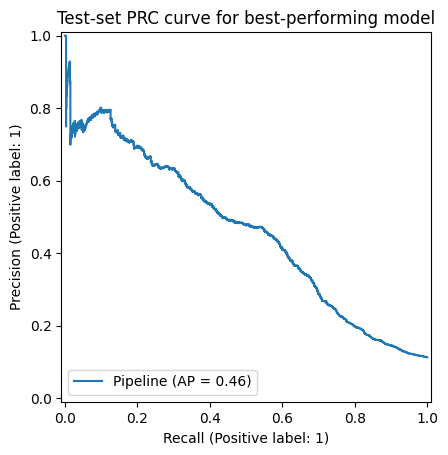

In [18]:
## Graph of test-set PRC curve for best model

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

best_model_name = results_grid_df[f'best_cv_score ({scoring})'].idxmax()
best_model = best_models[best_model_name]

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Test-set PRC curve for best-performing model")
plt.show()


# Analysis

Next we use our best-performing model to analyze how certain variables affect likelihood of customer acquisition.

In [19]:
# Get best continuous-output model, in case it is not already the best among all 4 model types.


contin_model_names = ['Log reg', 'SVM']
results_grid_contin_only = results_grid_df.loc[ contin_model_names ]
name_of_best_contin_model = results_grid_contin_only[f'best_cv_score ({scoring})'].idxmax()
best_contin_model = best_models[ name_of_best_contin_model ]


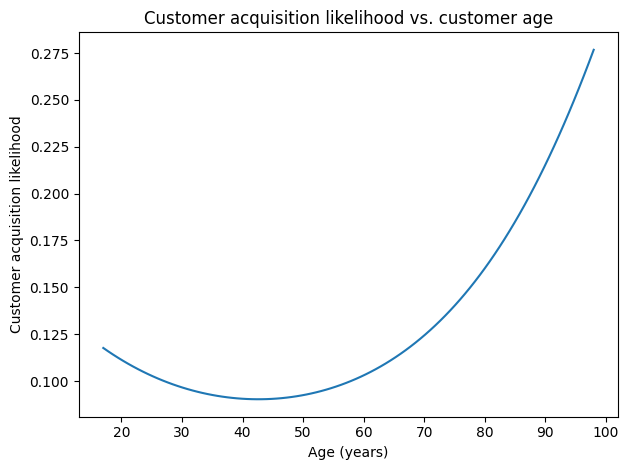

In [20]:
## Line plot showing how customer age affects likelihood of customer acquisition


# Sample 10 rows from test set
X_sample = X_test.sample(n=10, random_state=random_state)

# Populate vector of age values
plot_x_vals = np.linspace( X_train['age'].min() , X_train['age'].max() , 100 ) 

# Get predictions, averaged over the sampled rows
y_vals = []
for plot_x in plot_x_vals :
    X_sample['age'] = plot_x
    y_sample_prob = best_contin_model.predict_proba(X_sample)[:,1] # column 1 corresponds to "2nd class", which is y=1
    y_prob_avg_over_samples = y_sample_prob.mean()
    y_vals.append( y_prob_avg_over_samples )


# Generate plot
plt.plot(plot_x_vals,y_vals)
plt.title("Customer acquisition likelihood vs. customer age")
plt.xlabel("Age (years)"); plt.ylabel("Customer acquisition likelihood")
plt.tight_layout() 
plt.savefig('plots/plot_age.png')


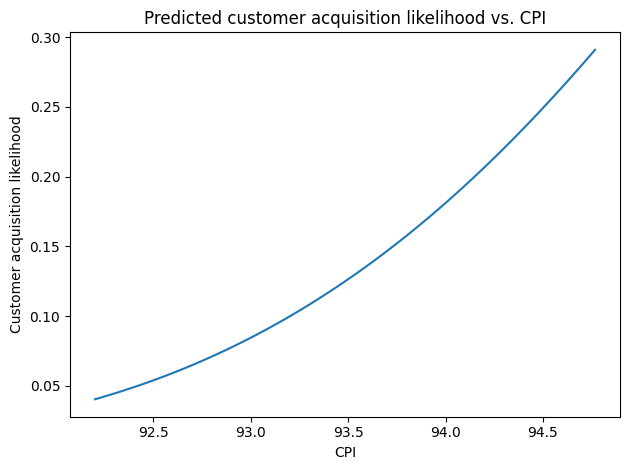

In [24]:
## Line plot showing how CPI affects likelihood of customer acquisition


# Sample 10 rows from test set
X_sample = X_test.sample(n=10, random_state=random_state)

# Populate vector of CPI values
plot_x_vals = np.linspace( X_train['cons.price.idx'].min() , X_train['cons.price.idx'].max() , 100 ) 

# Get predictions, averaged over the sampled rows
y_vals = []
for plot_x in plot_x_vals :
    X_sample['cons.price.idx'] = plot_x
    y_sample_prob = best_contin_model.predict_proba(X_sample)[:,1] # column 1 corresponds to "2nd class", which is y=1
    y_prob_avg_over_samples = y_sample_prob.mean()
    y_vals.append( y_prob_avg_over_samples )


# Generate plot
plt.plot(plot_x_vals,y_vals)
plt.title("Predicted customer acquisition likelihood vs. CPI")
plt.xlabel("CPI"); plt.ylabel("Customer acquisition likelihood")
plt.tight_layout() 
plt.savefig('plots/plot_cpi.png')

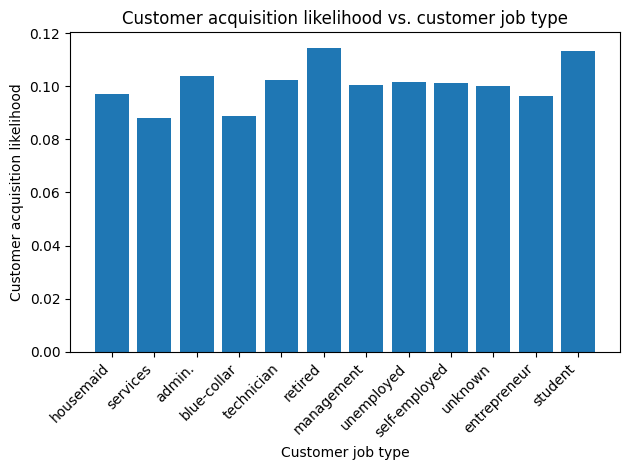

In [21]:
## Bar plot showing how customer age affects likelihood of customer acquisition


# Sample 10 rows from test set
X_sample = X_test.sample(n=10, random_state=random_state)

# Populate vector of age values
plot_x_vals = X['job'].unique() 

# Get predictions, averaged over the sampled rows
y_vals = []
for plot_x in plot_x_vals :
    X_sample['job'] = plot_x
    y_sample_prob = best_contin_model.predict_proba(X_sample)[:,1] # column 1 corresponds to "2nd class", which is y=1
    y_prob_avg_over_samples = y_sample_prob.mean()
    y_vals.append( y_prob_avg_over_samples )


# Generate plot
plt.bar(plot_x_vals,y_vals)
plt.title("Customer acquisition likelihood vs. customer job type")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Customer job type"); plt.ylabel("Customer acquisition likelihood")
plt.tight_layout() 
plt.savefig('plots/plot_job.png')


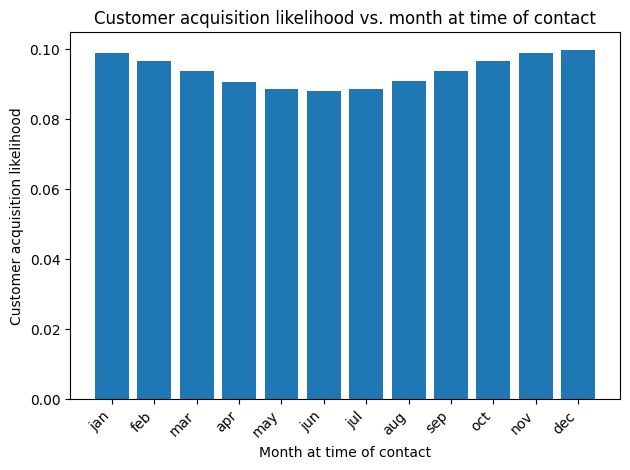

In [22]:
## Bar plot showing how month at time of contact affects likelihood of customer acquisition


# Sample 10 rows from test set
X_sample = X_test.sample(n=10, random_state=random_state)

# Populate vector of month values
plot_x_vals = list(month_mapping)

# Get predictions, averaged over the sampled rows
y_vals = []
for plot_x in plot_x_vals :
    X_sample['month'] = plot_x
    y_sample_prob = best_contin_model.predict_proba(X_sample)[:,1] # column 1 corresponds to "2nd class", which is y=1
    y_prob_avg_over_samples = y_sample_prob.mean()
    y_vals.append( y_prob_avg_over_samples )


# Generate plot
plt.bar(plot_x_vals,y_vals)
plt.title("Customer acquisition likelihood vs. month at time of contact")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Month at time of contact"); plt.ylabel("Customer acquisition likelihood")
plt.tight_layout() 
plt.savefig('plots/plot_month.png')


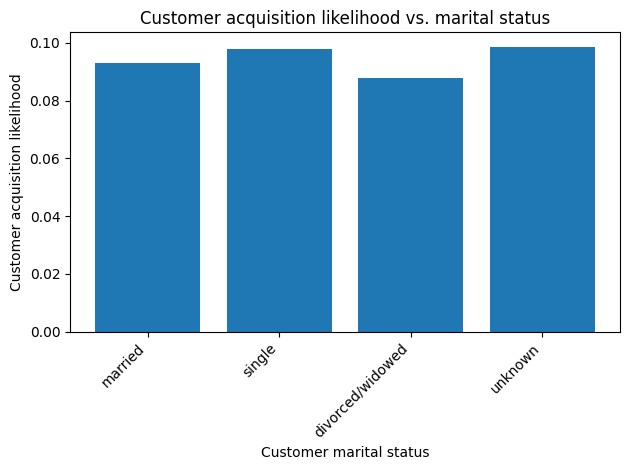

In [23]:
## Bar plot showing how customer marital status affects likelihood of customer acquisition


# Sample 10 rows from test set
X_sample = X_test.sample(n=10, random_state=random_state)

# Populate vector of marital status values
plot_x_vals = X['marital'].unique()

# Get predictions, averaged over the sampled rows
y_vals = []
for plot_x in plot_x_vals :
    X_sample['marital'] = plot_x
    y_sample_prob = best_contin_model.predict_proba(X_sample)[:,1] # column 1 corresponds to "2nd class", which is y=1
    y_prob_avg_over_samples = y_sample_prob.mean()
    y_vals.append( y_prob_avg_over_samples )


# Rename "divorced" to "divorced/widowed", since this is a more correct description
plot_x_vals[ plot_x_vals == "divorced" ] = "divorced/widowed"

# Generate plot
plt.bar(plot_x_vals,y_vals)
plt.title("Customer acquisition likelihood vs. marital status")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Customer marital status"); plt.ylabel("Customer acquisition likelihood")
plt.tight_layout() 
plt.savefig('plots/plot_marital.png')


##### Questions